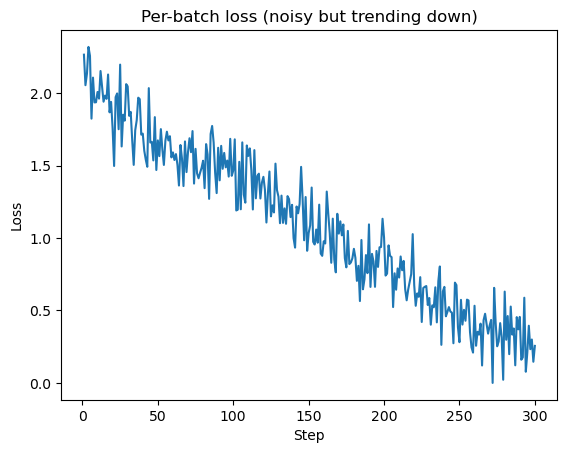

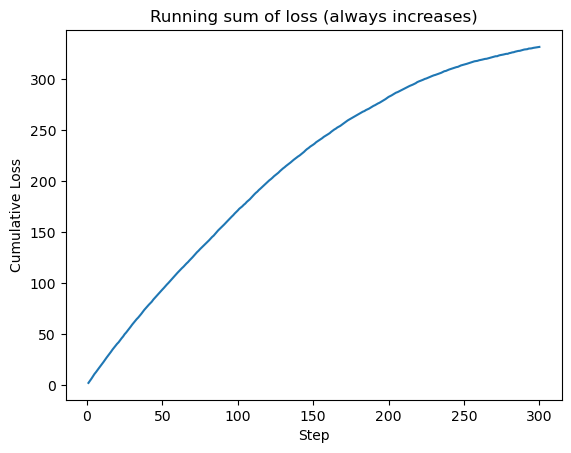

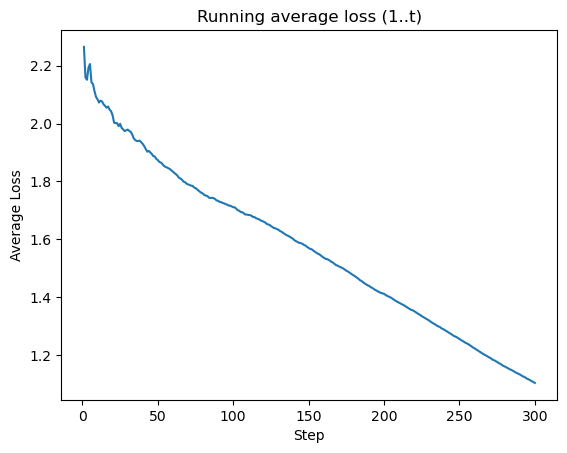

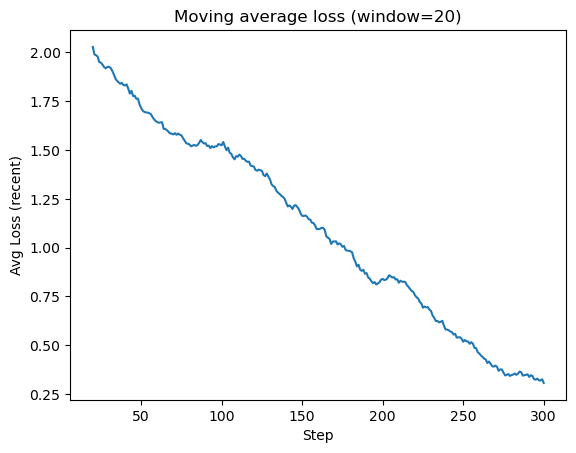

In [1]:
# Demo: visualize different loss summaries over training steps
# - Per-batch loss (noisy but trending down)
# - Running sum (monotonically increasing; not useful to judge progress)
# - Running average (average from step 1..t)
# - Moving average (windowed, e.g., last 20 steps)

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

steps = 300
true_trend = np.linspace(2.0, 0.2, steps)            # target decreasing trend
noise = np.random.normal(loc=0.0, scale=0.15, size=steps)
batch_loss = np.maximum(true_trend + noise, 0.0)      # per-batch loss (non-negative)

# Running sum
running_sum = np.cumsum(batch_loss)

# Running average
running_avg = running_sum / (np.arange(steps) + 1)

# Moving average (windowed)
window = 20
cumsum = np.cumsum(np.insert(batch_loss, 0, 0.0))
moving_avg = (cumsum[window:] - cumsum[:-window]) / window
# Pad the first (window-1) entries with NaN for visualization alignment
moving_avg_full = np.full(steps, np.nan)
moving_avg_full[window-1:] = moving_avg

# --- Plot 1: Per-batch loss ---
plt.figure()
plt.plot(np.arange(1, steps+1), batch_loss)
plt.title("Per-batch loss (noisy but trending down)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

# --- Plot 2: Running sum (monotonic increase) ---
plt.figure()
plt.plot(np.arange(1, steps+1), running_sum)
plt.title("Running sum of loss (always increases)")
plt.xlabel("Step")
plt.ylabel("Cumulative Loss")
plt.show()

# --- Plot 3: Running average ---
plt.figure()
plt.plot(np.arange(1, steps+1), running_avg)
plt.title("Running average loss (1..t)")
plt.xlabel("Step")
plt.ylabel("Average Loss")
plt.show()

# --- Plot 4: Moving average (window=20) ---
plt.figure()
plt.plot(np.arange(1, steps+1), moving_avg_full)
plt.title("Moving average loss (window=20)")
plt.xlabel("Step")
plt.ylabel("Avg Loss (recent)")
plt.show()


In [13]:
len(cumsum[:-290])

11

In [21]:
a=np.array([1,2,3,4,5,6,7])

In [25]:
a[:-3]

array([1, 2, 3, 4])

In [26]:
a[3:]

array([4, 5, 6, 7])

In [29]:
(a[3:]-a[:-3])/3

array([1., 1., 1., 1.])